## Daily Challenge: Logistic Regression for Admission Prediction


In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/BootGenAI/ex2data1.txt')
print(df.head())

# Assign column names for clarity
df.columns = ["Exam1", "Exam2", "Admitted"]

print(df.info())

   34.62365962451697  78.0246928153624  0
0          30.286711         43.894998  0
1          35.847409         72.902198  0
2          60.182599         86.308552  1
3          79.032736         75.344376  1
4          45.083277         56.316372  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam1     99 non-null     float64
 1   Exam2     99 non-null     float64
 2   Admitted  99 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 2.4 KB
None


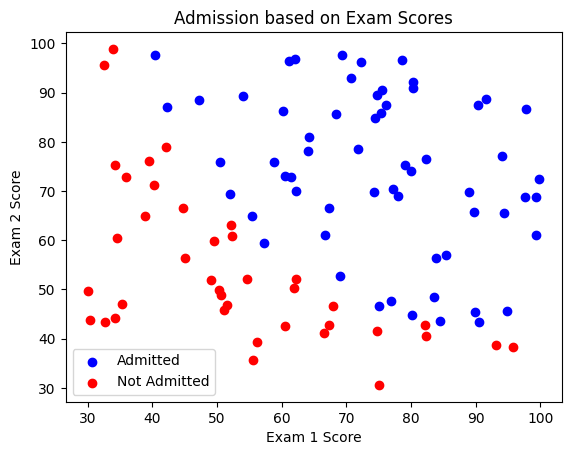

In [9]:
import matplotlib.pyplot as plt

# Scatter plot: Exam 1 vs Exam 2
admitted = df[df['Admitted'] == 1]
not_admitted = df[df['Admitted'] == 0]

plt.scatter(admitted['Exam1'], admitted['Exam2'], c='blue', label='Admitted')
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'], c='red', label='Not Admitted')

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.legend()
plt.title("Admission based on Exam Scores")
plt.show()


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Features (X) and target (y)
X = df[["Exam1", "Exam2"]]
y = df["Admitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # THIS for Same percentage of class 0 and class 1
)

# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)



LogisticRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


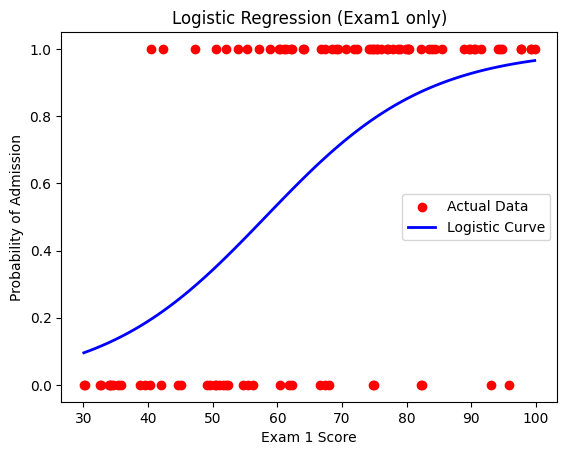

In [27]:
X_single = df[["Exam1"]]   # only one feature
y = df["Admitted"]

model_single = LogisticRegression()
model_single.fit(X_single, y)

# Range of Exam1 values
x_range = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
y_pred = model_single.predict_proba(x_range)[:,1]  # probability of admission

# Plot
plt.scatter(X_single, y, color="red", label="Actual Data")
plt.plot(x_range, y_pred, color="blue", linewidth=2, label="Logistic Curve")

plt.xlabel("Exam 1 Score")
plt.ylabel("Probability of Admission")
plt.title("Logistic Regression (Exam1 only)")
plt.legend()
plt.show()


In [16]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Coefficients and intercept (parameters of the hyperplane)
print("Weights:", model.coef_)
print("Bias:", model.intercept_)


Model Accuracy: 0.9
Weights: [[0.21975219 0.19586661]]
Bias: [-25.42063949]


### Logistic Regression Evaluation (Brief)

- **Accuracy**: 0.90 → strong performance.  
- **Weights**: Exam1 = 0.22, Exam2 = 0.20 → higher scores increase admission likelihood.  
- **Bias**: -25.42 → shifts the decision boundary.